In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as col
import Bayesian_Methods as Bayes
import Parameters as Pars
from functools import partial
import sys
from Full_Par_Method import Parameter_Processing
import Full_Par_Method
from multiprocess import Pool
from dynesty import DynamicNestedSampler, sampler, plotting
from getdist import plots, MCSamples

par_names = (Pars.psi0[0], Pars.m0[0], Pars.mass_norm[0], Pars.scatter[0], Pars.tau[0], Pars.gamma_inner[0])
parrange = ((-3.5,10.5,7.5,0,0.1,-1.5),(-1.5,12.5,9.5,1,11,0))
ndim = 6
Data = Parameter_Processing(Full_Par_Method.FidPars, load_strain = False)
Nano_strains = Data.CharStrainBound_Nano_15()[0]


In [81]:
Priors = DistObj.Priors(DistObj)
Priors.Uniform(1e-12)

NameError: name 'DistObj' is not defined

In [4]:
par_names = (Pars.psi0[0], Pars.m0[0], Pars.mass_norm[0], Pars.scatter[0], Pars.tau[0], Pars.gamma_inner[0])
parrange = ((-3.5,10.5,7.5,0,0.1,-1.5),(-1.5,12.5,9.5,1,11,0))
ndim = 6
Data = Parameter_Processing(Full_Par_Method.FidPars, load_strain = False)
Nano_strains = Data.CharStrainBound_Nano_15()[0]


In [38]:
parameters = np.linspace(parrange[:][0],parrange[:][1],10)

In [42]:
Varpar = parameters[:,0]

In [126]:
def Likelihood_Wrapper(parameters, par_names = par_names):
    par_dict = {key: value for key, value in zip(par_names,parameters)}
    likelihood = Parameter_Processing(par_dict,NUM_REALS = 100, load_strain = False).Quick_Likelihood()
    return likelihood

In [127]:
Likes = np.ones(len(Varpar))
for i,v in enumerate(Varpar):
    Parameter = np.insert(list(Full_Par_Method.FidPars.values())[1:], 0, v)
    Likes[i] = Likelihood_Wrapper(Parameter)
print(Likes)

19:17:05 INFO : No galaxy pair-fraction given, using galaxy merger-rate. [sam.py:__init__]
19:17:06 INFO : No GMT was provided, cannot calculate Galaxy-Merger based stalling. [sam.py:static_binary_density]
19:17:06 INFO : Adding MMbulge scatter (4.5000e-01) [sam.py:static_binary_density]
19:17:06 INFO : 	dens bef: (0.00e+00, 0.00e+00, 9.09e-72, 8.14e-04, 7.77e-02, 3.92e-01, 1.76e+00) [sam.py:static_binary_density]
19:17:16 INFO : Scatter added after 10.234034 sec [sam.py:static_binary_density]
19:17:16 INFO : 	dens aft: (1.71e-19, 1.54e-11, 7.05e-08, 2.39e-03, 1.63e-01, 4.18e-01, 1.61e+00) [sam.py:static_binary_density]
19:17:16 INFO : 	mass: 8.39e-02 ==> 1.86e-01 || change = 1.2232e+00 [sam.py:static_binary_density]
19:17:16 ERROR : Warning, significant change in number-mass!  mass: 8.39e-02 ==> 1.86e-01 || change = 1.2232e+00 [sam.py:static_binary_density]
19:17:16 INFO : `gmt_time` not calculated in SAM.  Setting to zeros. [sam.py:gwb]
Using the characteristic strain bound provided 

In [ ]:
#Need to rethink the error for M << N

(0.001, 1)

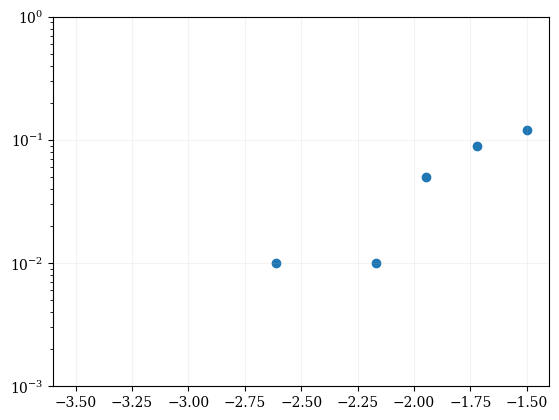

In [133]:
plt.scatter(Varpar,1 - Likes)
plt.yscale('log')
plt.ylim(1e-3,1)

In [45]:
list(Full_Par_Method.FidPars.values())[0:]

[-2.5, 11.5, 8.3, 0.45, 5.55, -0.75]